In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix # Added confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import StandardScaler

---

###**Data Preparation**

---

In [267]:
df_combats = pd.read_csv('combats.csv')
df_combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [268]:
df_pokemon = pd.read_csv('/content/pokemon.csv')
df_pokemon.head(63)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
58,59,Persian,Normal,NaN,65,70,60,65,65,115,1,False
59,60,Psyduck,Water,NaN,50,52,48,65,50,55,1,False
60,61,Golduck,Water,NaN,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,NaN,40,80,35,35,45,70,1,False


---

**Fix missing values:**
* Fill the missing Name for Pokemon #62 (Primeape).
* Handle NaN values in Type 2 (mark as “None” if missing).

---

In [269]:
# Fill the name to #62 Pokemon
df_pokemon.loc[df_pokemon['#'] == 63, ['Name']] = 'Primeape'
print(df_pokemon.loc[df_pokemon['#'] == 63, ['Name']])

        Name
62  Primeape


In [270]:
# replace NaN in Type 2 to "None"
df_pokemon['Type 2'] = df_pokemon['Type 2'].fillna('None')

In [271]:
#check result
df_pokemon.isnull().sum() / len(df_pokemon) * 100

,0
#,0.0
Name,0.0
Type 1,0.0
Type 2,0.0
HP,0.0
Attack,0.0
Defense,0.0
Sp. Atk,0.0
Sp. Def,0.0
Speed,0.0


---

**Calculate each Pokemon’s win percentage using the combat data.**

---

In [272]:
win_percent = df_combats['Winner'].value_counts(normalize=True) * 100
win_percent = win_percent.sort_index(ascending=True)
win_percent.round(2)

,proportion
Winner,
1,0.07
2,0.09
3,0.18
4,0.14
5,0.11
...,...
796,0.08
797,0.23
798,0.12


###**Exploratory Analysis & Visualization**



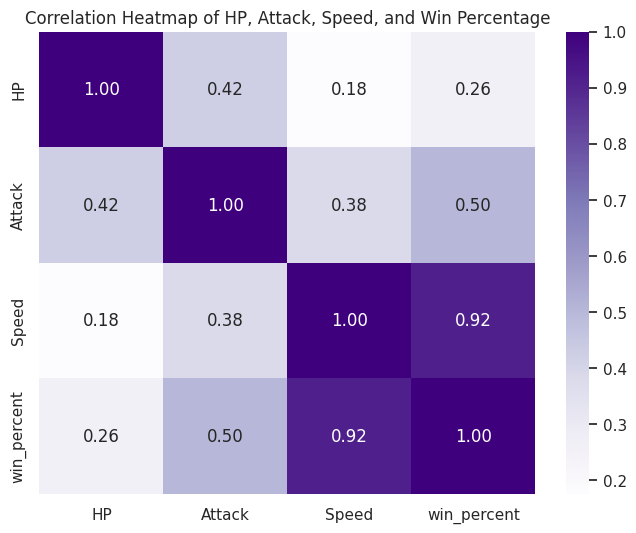

In [273]:
# add win_percent in df_pokemon
df_pokemon['win_percent'] = df_pokemon['#'].map(win_percent)

#  relationships between stats
corr_matrix = df_pokemon[['HP', 'Attack', 'Speed', 'win_percent']].corr()

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Purples', fmt=".2f")  # 'BuPu' — blue-purple
plt.title('Correlation Heatmap of HP, Attack, Speed, and Win Percentage')
plt.show()

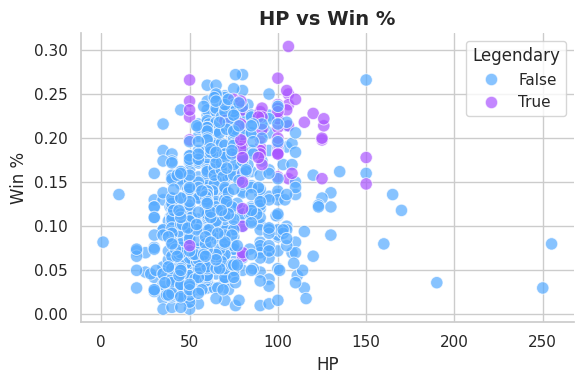

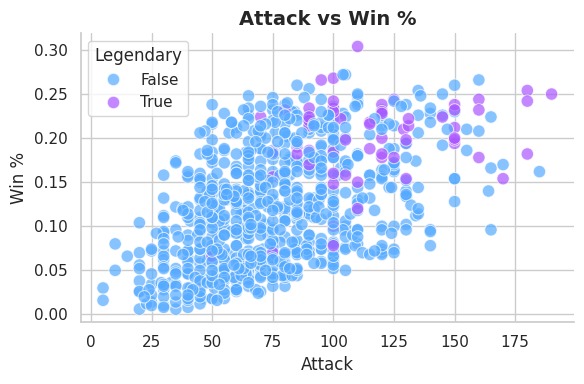

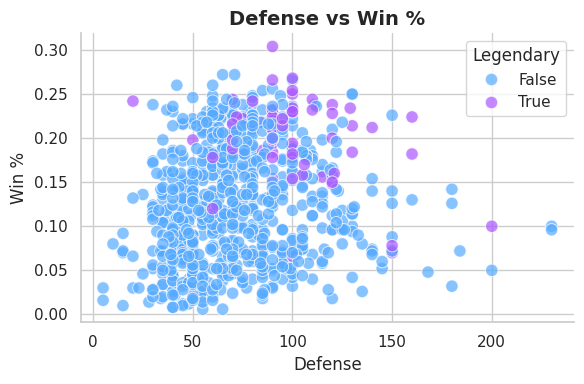

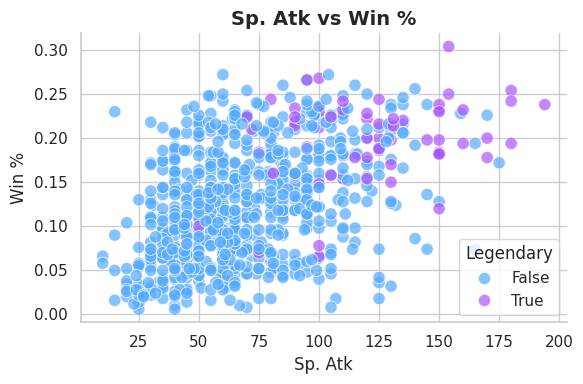

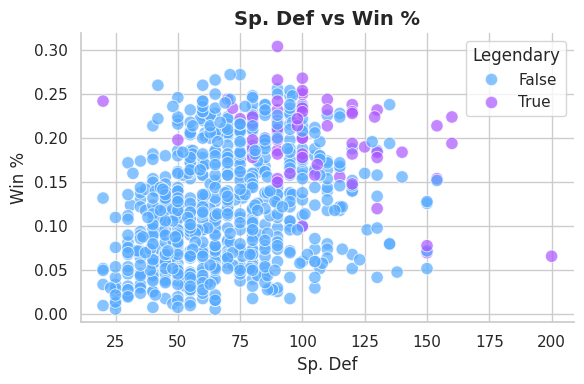

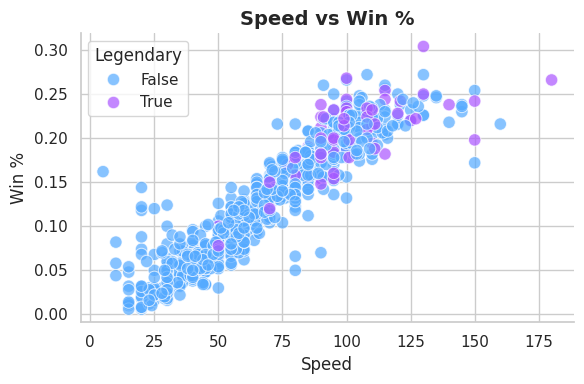

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

# all stats and win_percent
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
for stat in stats:
    plt.figure(figsize=(6,4))

    # Legendary color
    if 'Legendary' in df_pokemon.columns:
        sns.scatterplot(
            data=df_pokemon,
            x=stat, y='win_percent',
            hue='Legendary',
            palette='cool',
            alpha=0.7,
            edgecolor='w',
            s=80)
    else:
        sns.scatterplot(
            data=df_pokemon,
            x=stat, y='win_percent',
            color='#544FCB',
            alpha=0.7,
            edgecolor='w',
            s=80)


    plt.title(f'{stat} vs Win %', fontsize=14, weight='bold')
    plt.xlabel(stat)
    plt.ylabel('Win %')
    sns.despine()
    plt.tight_layout()
    plt.show()

---

* Each plot shows the relationship between one **battle stat** and the **win percentage**

* Each dot is a Pokemon.
* The color shows if it is a legendary Pokemon or not.

---

**Summary:**
* Most battle stats have a weak or moderate positive correlation with win_percent — higher stats usually mean more wins.
* The clearest effect is often seen with *Attack* and *Speed*.
* Legendary Pokemon (if present) usually have higher win rates and higher stats.
* There is no perfect linear relationship: many factors together influence the result, not just one stat.


**Analyze the top 10 Pokemon by win percentage and their stats.**


In [275]:
# Get the top 10 Pokemon IDs
top10_ids = win_percent.sort_values(ascending=False).head(10)
top10_ids

,proportion
Winner,
163,0.304
154,0.272
438,0.272
428,0.268
314,0.266
432,0.266
214,0.260
394,0.260
249,0.256


In [276]:
# Filter df_pokemon for top 10 ID
# set index to '#'
top10_stats = df_pokemon[df_pokemon['#'].isin(top10_ids.index)].set_index('#')

# Reorder the DataFrame based on the order of ID
top10_stats = top10_stats.loc[top10_ids.index]

display(top10_stats[['Name', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'win_percent']])

,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,win_percent
Winner,,,,,,,,
163,Mewtwo,106,110,90,154,90,130,0.304
154,Aerodactyl,80,105,65,60,75,130,0.272
438,Infernape,76,104,71,104,71,108,0.272
428,Jirachi,100,100,100,100,100,100,0.268
314,Slaking,150,160,100,95,65,100,0.266
432,Deoxys Speed Forme,50,95,90,95,90,180,0.266
214,Murkrow,60,85,42,85,42,91,0.260
394,Mega Absol,65,150,60,115,60,115,0.260
249,Mega Houndoom,75,90,90,140,90,115,0.256


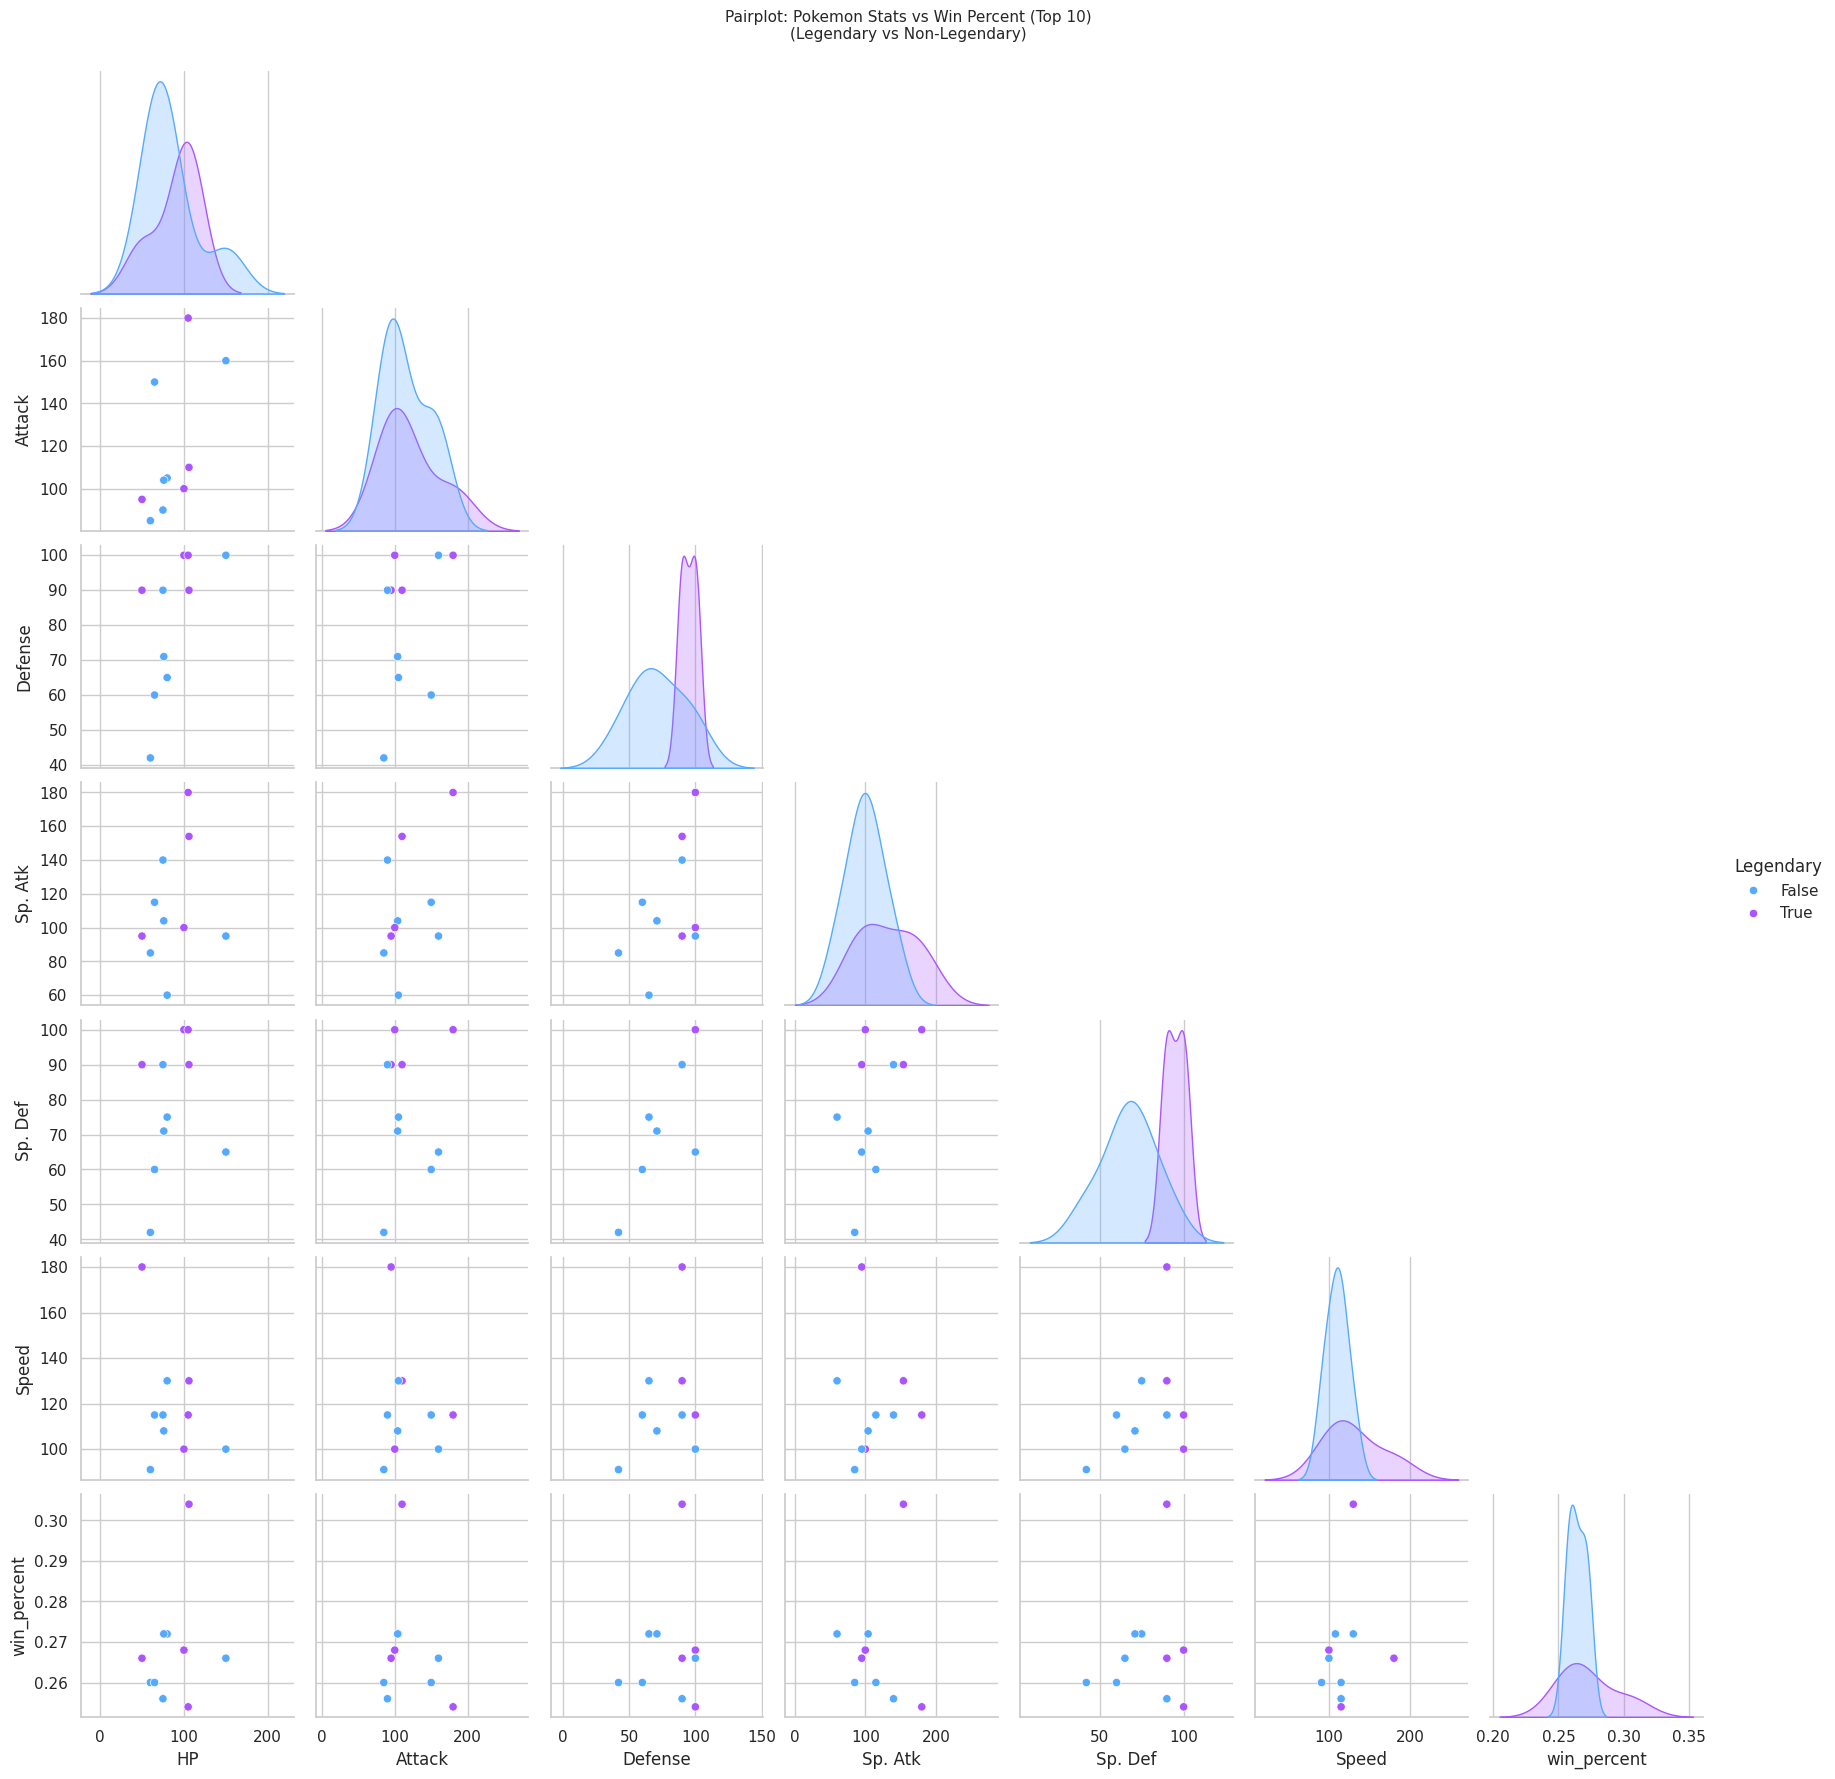

In [277]:
import seaborn as sns
import matplotlib.pyplot as plt

# Если столбца 'Legendary' нет — добавь его из исходного датафрейма
if 'Legendary' not in top10_stats.columns:
    top10_stats['Legendary'] = df_pokemon.set_index('#').loc[top10_stats.index]['Legendary']

cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'win_percent', 'Legendary']

# Pairplot с цветом по Legendary
sns.pairplot(top10_stats[cols],
             diag_kind='kde',
             hue='Legendary',
             palette='cool',
             corner=True)

plt.suptitle('Pairplot: Pokemon Stats vs Win Percent (Top 10)\n(Legendary vs Non-Legendary)',
             y=1.02, fontsize=11)
plt.show()

---

* Most top-10 win_percent Pokemon are legendary (violet), but some are not.
* High win_percent isn't based on one stat — both legendary and regular Pokemon have varied stats.
* Legendary Pokemon often have higher Speed and Attack, but not always.
* There's no strong linear link between stats and win_percent — it depends on the combination.

**Summary:**
Being legendary or having one high stat is not enough. Pokemon with balanced, strong stats do best in win_percent top-10.

---



---

###**Machine Learning**

---

In [278]:
# Transform the Winner column: 0 - the first Pokemon won, 1 - the second Pokemon won
df_combats['Winner'] = np.where(df_combats['First_pokemon'] == df_combats['Winner'], 0, 1)

In [279]:
# Merge the characteristics of both pokemons into each battle row
df = df_combats.merge(df_pokemon.add_suffix('_1'), left_on='First_pokemon', right_on='#_1')
df = df.merge(df_pokemon.add_suffix('_2'), left_on='Second_pokemon', right_on='#_2')

# List of main stats to compare
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Calculate the difference in stats between the first and second pokemon
for stat in stats:
    df[f'diff_{stat.lower()}'] = df[f'{stat}_1'] - df[f'{stat}_2']

# Add binary flags for legendary status
df['is_legend_1'] = df['Legendary_1'].astype(int)
df['is_legend_2'] = df['Legendary_2'].astype(int)

# Create a list of features for model training
features = []
# Add all differences
features += [f'diff_{stat.lower()}' for stat in stats]
# Optionally, add absolute values for both pokemons
features += [f'{stat}_1' for stat in stats] + [f'{stat}_2' for stat in stats]
# Add legendary flags
features += ['is_legend_1', 'is_legend_2']


In [280]:
X = df[features]
y = df['Winner']

# Train/test split (stratify!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


---

* We notice that we have a large class imbalance, so we have to use SMOTE.

---

LogReg Accuracy: 0.882
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4720
           1       0.91      0.86      0.89      5280

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



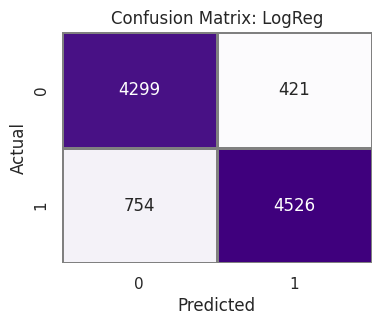

RF Accuracy: 0.912
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4720
           1       0.95      0.88      0.91      5280

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



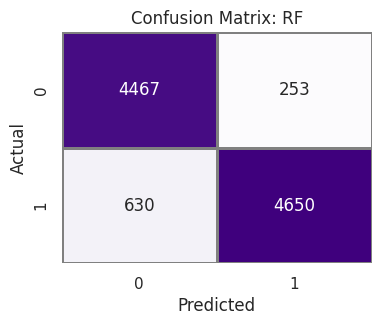

XGB Accuracy: 0.773
              precision    recall  f1-score   support

           0       0.70      0.92      0.79      4720
           1       0.90      0.64      0.75      5280

    accuracy                           0.77     10000
   macro avg       0.80      0.78      0.77     10000
weighted avg       0.80      0.77      0.77     10000



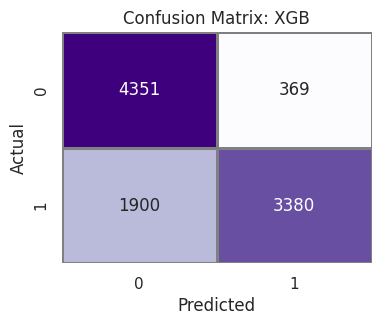

In [281]:
# Scale only numeric features (do not scale binary/categorical columns)
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

# Train and evaluate models as before
for model, name in zip([lr, rf, xgb], ['LogReg', 'RF', 'XGB']):
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f'{name} Accuracy: {accuracy_score(y_test, y_pred):.3f}')
    print(classification_report(y_test, y_pred))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, linewidths=1, linecolor='grey')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

---

* Compare model performance using Mean Absolute Error (MAE).

---


In [282]:
from sklearn.metrics import mean_absolute_error

# prediction for each model
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)
xgb_preds = xgb.predict(X_test)

# MAE for each model
mae_lr = mean_absolute_error(y_test, lr_preds)
mae_rf = mean_absolute_error(y_test, rf_preds)
mae_xgb = mean_absolute_error(y_test, xgb_preds)

print(f"Linear Regression MAE: {mae_lr:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")

Linear Regression MAE: 0.1175
Random Forest MAE: 0.0883
XGBoost MAE: 0.2269


* **Random Forest** has the **lowest MAE (0.0883)**, so it predicts the winners more accurately than **Linear Regression (0.1175)** or **XGBoost (0.2269).**
* Lower MAE means better performance.